<a href="https://colab.research.google.com/github/remyaP12/labcycle/blob/main/scania_catboost_comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install required packages
!pip install -q optuna xgboost catboost imbalanced-learn statsmodels scikit-learn pandas numpy matplotlib seaborn
print(' All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 10.7 MB/s eta 0:00:00
 All packages installed.


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, confusion_matrix,
                             classification_report)
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

print(' Libraries loaded.')

 Libraries loaded.


In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
DATA_DIR = "/content/drive/MyDrive/scania"
FILE_MAP = {
    'op_train': os.path.join(DATA_DIR, 'train_operational_readouts.csv'),
    'op_val': os.path.join(DATA_DIR, 'validation_operational_readouts.csv'),
    'op_test': os.path.join(DATA_DIR, 'test_operational_readouts.csv'),

    'spec_train': os.path.join(DATA_DIR, 'train_specifications.csv'),
    'spec_val': os.path.join(DATA_DIR, 'validation_specifications.csv'),
    'spec_test': os.path.join(DATA_DIR, 'test_specifications.csv'),

    'repair_train': os.path.join(DATA_DIR, 'train_tte.csv'),
    'repair_val': os.path.join(DATA_DIR, 'validation_labels.csv'),
    'repair_test': os.path.join(DATA_DIR, 'test_labels.csv'),
}
def load_csv_safe(path, label):
    try:
        df = pd.read_csv(path, low_memory=False)
        print(f" {label}: {df.shape[0]:,} rows × {df.shape[1]} columns")
        return df
    except Exception as e:
        print(f" {label}")
        print("Path :", path)
        print("Error:", e)
        return None

        print("Loading datasets...\n")

op_train = load_csv_safe(FILE_MAP['op_train'], 'Operational Train')
op_val = load_csv_safe(FILE_MAP['op_val'], 'Operational Validation')
op_test = load_csv_safe(FILE_MAP['op_test'], 'Operational Test')

spec_train = load_csv_safe(FILE_MAP['spec_train'], 'Specification Train')
spec_val = load_csv_safe(FILE_MAP['spec_val'], 'Specification Validation')
spec_test = load_csv_safe(FILE_MAP['spec_test'], 'Specification Test')

repair_train = load_csv_safe(FILE_MAP['repair_train'], 'Repair Train')
repair_val = load_csv_safe(FILE_MAP['repair_val'], 'Repair Validation')
repair_test = load_csv_safe(FILE_MAP['repair_test'], 'Repair Test')

 Operational Train: 1,122,452 rows × 107 columns
 Operational Validation: 196,227 rows × 107 columns
 Operational Test: 198,140 rows × 107 columns
 Specification Train: 23,550 rows × 9 columns
 Specification Validation: 5,046 rows × 9 columns
 Specification Test: 5,045 rows × 9 columns
 Repair Train: 23,550 rows × 3 columns
 Repair Validation: 5,046 rows × 2 columns
 Repair Test: 5,045 rows × 2 columns


In [5]:
# ── Quick sanity check ──
print('\n=== COLUMN NAMES (first 10 per file) ===')
for name, df in [('op_train', op_train), ('spec_train', spec_train), ('repair_train', repair_train)]:
    if df is not None:
        print(f'\n{name}: {list(df.columns[:10])} ...')


=== COLUMN NAMES (first 10 per file) ===

op_train: ['vehicle_id', 'time_step', '171_0', '666_0', '427_0', '837_0', '167_0', '167_1', '167_2', '167_3'] ...

spec_train: ['vehicle_id', 'Spec_0', 'Spec_1', 'Spec_2', 'Spec_3', 'Spec_4', 'Spec_5', 'Spec_6', 'Spec_7'] ...

repair_train: ['vehicle_id', 'length_of_study_time_step', 'in_study_repair'] ...


In [6]:
def detect_key_col(df, candidates):
    """Return the first candidate column name found in df."""
    if df is None:
        return None
    for c in candidates:
        if c in df.columns:
            return c
    # fuzzy: case-insensitive
    lower = {col.lower(): col for col in df.columns}
    for c in candidates:
        if c.lower() in lower:
            return lower[c.lower()]
    return df.columns[0]   # fallback: first column

ID_COL        = detect_key_col(op_train, ['variable_id', 'vehicle_id', 'id'])
TIMESTEP_COL  = detect_key_col(op_train, ['time_step', 'timestep', 'time'])
REPAIR_COL    = detect_key_col(repair_train, ['in_study_repair', 'repair', 'failure', 'target', 'label'])
STUDY_TIME_COL= detect_key_col(repair_train, ['length_of_study_time_step', 'study_time', 'length'])

print(f'ID column         : {ID_COL}')
print(f'Time-step column  : {TIMESTEP_COL}')
print(f'Repair/target col : {REPAIR_COL}')
print(f'Study time col    : {STUDY_TIME_COL}')

# ── Validate repair column values ──
if repair_train is not None and REPAIR_COL:
    print(f'\nUnique values in repair column: {sorted(repair_train[REPAIR_COL].dropna().unique())}')

ID column         : vehicle_id
Time-step column  : time_step
Repair/target col : in_study_repair
Study time col    : length_of_study_time_step

Unique values in repair column: [np.int64(0), np.int64(1)]


In [7]:
def select_last_observation(op_df, id_col, timestep_col):
    """
    Section 3.1: Select the last time-step observation for each vehicle.
    This captures the most recent system state before a failure/maintenance event.
    """
    if timestep_col and timestep_col in op_df.columns:
        last_obs = (
            op_df.sort_values(timestep_col)
                 .groupby(id_col, as_index=False)
                 .last()
        )
    else:
        # If no time_step column, take last row per vehicle
        last_obs = op_df.groupby(id_col, as_index=False).last()
    print(f'  Last-observation selection: {len(last_obs):,} unique vehicles retained')
    return last_obs

def merge_subsets(op_last, spec_df, repair_df, id_col):
    """
    Section 3.1: Merge the three subsets on the vehicle ID key.
    """
    df = op_last.merge(spec_df, on=id_col, how='left', suffixes=('', '_spec'))
    df = df.merge(repair_df, on=id_col, how='left', suffixes=('', '_repair'))
    return df

# ── Training set ──
print('=== TRAINING SET ===')
op_train_last = select_last_observation(op_train, ID_COL, TIMESTEP_COL)
train_merged  = merge_subsets(op_train_last, spec_train, repair_train, ID_COL)
print(f'  Merged training shape: {train_merged.shape}  (paper reports 23,550 × 115)')

# ── Validation set ──
print('\n=== VALIDATION SET ===')
op_val_last  = select_last_observation(op_val, ID_COL, TIMESTEP_COL)
val_merged   = merge_subsets(op_val_last, spec_val, repair_val, ID_COL)
print(f'  Merged validation shape: {val_merged.shape}')

# ── Test set ──
print('\n=== TEST SET ===')
op_test_last = select_last_observation(op_test, ID_COL, TIMESTEP_COL)
test_merged  = merge_subsets(op_test_last, spec_test, repair_test, ID_COL)
print(f'  Merged test shape: {test_merged.shape}')

=== TRAINING SET ===
  Last-observation selection: 23,550 unique vehicles retained
  Merged training shape: (23550, 117)  (paper reports 23,550 × 115)

=== VALIDATION SET ===
  Last-observation selection: 5,046 unique vehicles retained
  Merged validation shape: (5046, 116)

=== TEST SET ===
  Last-observation selection: 5,045 unique vehicles retained
  Merged test shape: (5045, 116)


In [8]:
# ── Detect target column in validation/test (multiclass: 0-4) ──
# TARGET_COL = detect_key_col(val_merged, ['class', 'target', 'label', 'failure_class',
#                                           'remaining_class', REPAIR_COL])
TARGET_COL = detect_key_col(
    val_merged,
    ['class_label', 'class', 'label',
     'failure_class', 'remaining_class',
     REPAIR_COL, 'target']
)
print(f'Target column for val/test: {TARGET_COL}')
print(f'Unique target values: {sorted(val_merged[TARGET_COL].dropna().unique())}')

Target column for val/test: class_label
Unique target values: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


In [9]:
#---
# Recreate validation and test labels
y_val = val_merged[TARGET_COL].values
y_test = test_merged[TARGET_COL].values

print("y_val classes:", np.unique(y_val))
print("y_test classes:", np.unique(y_test))

y_val classes: [0 1 2 3 4]
y_test classes: [0 1 2 3 4]


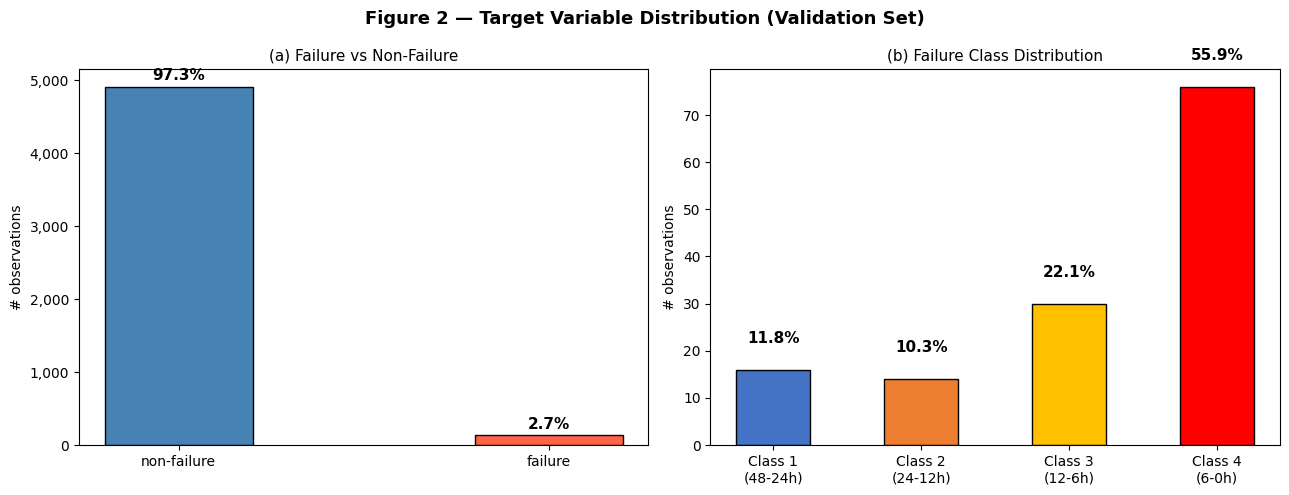


Class distribution summary:
class_label
Class 0 (no failure)    4910
Class 1                   16
Class 2                   14
Class 3                   30
Class 4                   76
Name: count, dtype: int64


In [10]:
# ── Figure 2 reproduction ──
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 2 — Target Variable Distribution (Validation Set)', fontsize=13, fontweight='bold')

val_target = val_merged[TARGET_COL].dropna()

# Panel a: failure vs non-failure
binary_counts = pd.Series({
    'non-failure': (val_target == 0).sum(),
    'failure':     (val_target != 0).sum()
})
colors_a = ['steelblue', 'tomato']
bars_a = axes[0].bar(binary_counts.index, binary_counts.values, color=colors_a, edgecolor='black', width=0.4)
for bar, pct in zip(bars_a, 100 * binary_counts / binary_counts.sum()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('(a) Failure vs Non-Failure', fontsize=11)
axes[0].set_ylabel('# observations')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# Panel b: failure classes 1-4
failure_counts = val_target[val_target != 0].value_counts().sort_index()
class_labels = {1: 'Class 1\n(48-24h)', 2: 'Class 2\n(24-12h)',
                3: 'Class 3\n(12-6h)', 4: 'Class 4\n(6-0h)'}
x_labels = [class_labels.get(c, f'Class {c}') for c in failure_counts.index]
colors_b = ['#4472C4', '#ED7D31', '#FFC000', '#FF0000']
bars_b = axes[1].bar(x_labels, failure_counts.values,
                     color=colors_b[:len(failure_counts)], edgecolor='black', width=0.5)
for bar, pct in zip(bars_b, 100 * failure_counts / failure_counts.sum()):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[1].set_title('(b) Failure Class Distribution', fontsize=11)
axes[1].set_ylabel('# observations')

plt.tight_layout()
plt.savefig('figure2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nClass distribution summary:')
print(val_target.value_counts().sort_index().rename({0:'Class 0 (no failure)',1:'Class 1',2:'Class 2',3:'Class 3',4:'Class 4'}))

In [11]:
# ─────────────────────────────────────────
# 5a. Identify column types
# ─────────────────────────────────────────
def identify_column_types(df, id_col, target_col=None):
    """Separate numerical operational columns from categorical spec columns."""
    # Exclude ID and target
    exclude = {id_col}
    if target_col and target_col in df.columns:
        exclude.add(target_col)

    # Categorical: columns whose name contains 'cat', 'spec', or dtype is object
    cat_cols = [
        c for c in df.columns
        if c not in exclude and (
            df[c].dtype == 'object' or
            any(kw in c.lower() for kw in ['cat', 'spec', 'type', 'model', 'config'])
        )
    ]
    num_cols = [
        c for c in df.columns
        if c not in exclude and c not in cat_cols
    ]
    return num_cols, cat_cols

num_cols_train, cat_cols_train = identify_column_types(train_merged, ID_COL, REPAIR_COL)
print(f'Numerical columns : {len(num_cols_train)}')
print(f'Categorical columns : {len(cat_cols_train)}')
if cat_cols_train:
    print(f'  Sample cat cols: {cat_cols_train[:8]}')

Numerical columns : 107
Categorical columns : 8
  Sample cat cols: ['Spec_0', 'Spec_1', 'Spec_2', 'Spec_3', 'Spec_4', 'Spec_5', 'Spec_6', 'Spec_7']


In [12]:
# ─────────────────────────────────────────
# 5b. Combine categorical spec variables → single 'model' variable (Section 3.2 step 1)
# ─────────────────────────────────────────
def combine_spec_columns(df, cat_cols):
    """Concatenate categorical spec columns into a single 'model' identifier."""
    if not cat_cols:
        print('  No categorical columns found to combine.')
        return df
    df = df.copy()
    df['model'] = df[cat_cols].astype(str).apply(lambda row: '_'.join(row), axis=1)
    n_models = df['model'].nunique()
    print(f'  Created "model" column — {n_models:,} unique truck models  (paper: 3,607)')
    return df

train_merged = combine_spec_columns(train_merged, cat_cols_train)
val_merged   = combine_spec_columns(val_merged,   identify_column_types(val_merged,  ID_COL, TARGET_COL)[1])
test_merged  = combine_spec_columns(test_merged,  identify_column_types(test_merged, ID_COL, TARGET_COL)[1])

  Created "model" column — 3,607 unique truck models  (paper: 3,607)
  Created "model" column — 1,393 unique truck models  (paper: 3,607)
  Created "model" column — 1,405 unique truck models  (paper: 3,607)


In [13]:
# ─────────────────────────────────────────
# 5c. Missing value imputation (Section 3.2 step 2)
# Formula: value_i = (value_{i-1} + value_{i-2})/2 + (value_{i-1} - value_{i-2})
#          i.e. linear extrapolation from two previous time steps
# ─────────────────────────────────────────
def temporal_extrapolate(v_prev, v_prev2):
    return (v_prev + v_prev2) / 2 + (v_prev - v_prev2)


def impute_missing_values(df, num_cols, op_df_full, id_col, timestep_col):

    df = df.copy()

    missing_before = df[num_cols].isnull().sum().sum()
    print(f"  Missing values before imputation: {missing_before:,}")

    two_prev = {}

    if timestep_col and timestep_col in op_df_full.columns:

        sorted_op = op_df_full.sort_values([id_col, timestep_col])

        # only operational columns
        valid_num_cols = [c for c in num_cols if c in sorted_op.columns]

        for vid, grp in sorted_op.groupby(id_col):

            if len(grp) >= 2:

                prev1 = grp.iloc[-2][valid_num_cols]

                prev2 = grp.iloc[-3][valid_num_cols] if len(grp) >= 3 else None

                two_prev[vid] = (prev1, prev2)

    for col in num_cols:

        if df[col].isna().sum() == 0:
            continue

        mask = df[col].isna()

        for idx in df[mask].index:

            vid = df.at[idx, id_col]

            if (
                col in valid_num_cols
                and vid in two_prev
                and two_prev[vid][1] is not None
            ):

                prev1, prev2 = two_prev[vid]

                if pd.notna(prev1[col]) and pd.notna(prev2[col]):

                    df.at[idx, col] = temporal_extrapolate(
                        prev1[col],
                        prev2[col]
                    )

                    continue

            if "model" in df.columns:

                model = df.at[idx, "model"]

                med = df.loc[df["model"] == model, col].median()

                if pd.notna(med):

                    df.at[idx, col] = med

                    continue

            df.at[idx, col] = df[col].median()

    missing_after = df[num_cols].isnull().sum().sum()

    print(f"  Missing values after imputation: {missing_after:,}")

    return df

# Refresh num_cols after adding 'model'
# num_cols_train, _ = identify_column_types(train_merged, ID_COL, REPAIR_COL)
num_cols_train, _ = identify_column_types(train_merged, ID_COL, REPAIR_COL)

# Keep only operational columns
num_cols_train = [c for c in num_cols_train if c in op_train.columns]
num_cols_train = [c for c in num_cols_train if c != 'model']

print('Imputing training set …')
train_merged = impute_missing_values(train_merged, num_cols_train, op_train, ID_COL, TIMESTEP_COL)

num_cols_val, _ = identify_column_types(val_merged, ID_COL, TARGET_COL)
num_cols_val = [c for c in num_cols_val if c != 'model']
print('\nImputing validation set …')
val_merged = impute_missing_values(val_merged, num_cols_val, op_val, ID_COL, TIMESTEP_COL)

num_cols_test, _ = identify_column_types(test_merged, ID_COL, TARGET_COL)
num_cols_test = [c for c in num_cols_test if c != 'model']
print('\nImputing test set …')
test_merged = impute_missing_values(test_merged, num_cols_test, op_test, ID_COL, TIMESTEP_COL)

Imputing training set …
  Missing values before imputation: 21
  Missing values after imputation: 0

Imputing validation set …
  Missing values before imputation: 0
  Missing values after imputation: 0

Imputing test set …
  Missing values before imputation: 22
  Missing values after imputation: 0


In [14]:
# ─────────────────────────────────────────
# 5d. Handle corrupted sensor data (resets / counter anomalies)
# Paper mentions 282,425 corrupted data points across the full dataset.
# Strategy: clip negative differences in cumulative counters
# ─────────────────────────────────────────
def handle_corrupted_sensors(df, num_cols):
    """
    Operational sensor values are cumulative counters/histograms.
    Negative values (counter resets) are replaced with 0.
    Extreme outliers (>99.9th percentile) are winsorized.
    """
    df = df.copy()
    n_corrupted = 0
    for col in num_cols:
        neg_mask = df[col] < 0
        n_corrupted += neg_mask.sum()
        df.loc[neg_mask, col] = 0
        # Winsorize at 99.9th percentile
        upper = df[col].quantile(0.999)
        df.loc[df[col] > upper, col] = upper
    print(f'  Corrupted / negative sensor readings clamped: {n_corrupted:,}')
    return df

print('Handling corrupted sensor data …')
train_merged = handle_corrupted_sensors(train_merged, num_cols_train)
val_merged   = handle_corrupted_sensors(val_merged,   num_cols_val)
test_merged  = handle_corrupted_sensors(test_merged,  num_cols_test)

Handling corrupted sensor data …
  Corrupted / negative sensor readings clamped: 0
  Corrupted / negative sensor readings clamped: 0
  Corrupted / negative sensor readings clamped: 0


In [15]:
# ─────────────────────────────────────────
# 6a. Target variable engineering
# ─────────────────────────────────────────
# The paper's class mapping (Table 1):
# Class 0: No failure event
# Class 1: failure within 48-24 time units
# Class 2: failure within 24-12 time units
# Class 3: failure within 12-6 time units
# Class 4: failure within 6-0 time units

CLASS_MAP = {
    'time_to_failure': {
        lambda t: t == 0 or pd.isna(t): 0,
    }
}

def build_multiclass_target(df, repair_col, study_time_col):
    """
    Convert binary repair flag + time to multiclass following Table 1.
    repair_col values: 0 = no failure, 1 = failure during study period
    study_time_col: remaining time until failure (if available)
    """
    df = df.copy()

    # Case 1: target is already multiclass 0-4
    if df[repair_col].nunique() > 2:
        print(f'  Target column already multiclass: {sorted(df[repair_col].unique())}')
        df['target'] = df[repair_col].fillna(0).astype(int)
        return df

    # Case 2: binary flag — need time-to-failure to determine class
    # If study_time_col present, use it; else assign Class 1 for all failures
    df['target'] = 0  # default: no failure
    failure_mask = df[repair_col] == 1

    if study_time_col and study_time_col in df.columns:
        t = df.loc[failure_mask, study_time_col]
        df.loc[failure_mask & (t > 24), 'target'] = 1  # 48-24h
        df.loc[failure_mask & (t > 12) & (t <= 24), 'target'] = 2
        df.loc[failure_mask & (t > 6)  & (t <= 12), 'target'] = 3
        df.loc[failure_mask & (t <= 6), 'target'] = 4
        # Paper keeps observations >48h as Class 1 (Section 3.3)
        still_zero = failure_mask & (df['target'] == 0)
        df.loc[still_zero, 'target'] = 1
    else:
        df.loc[failure_mask, 'target'] = 1

    print(f'  Target distribution after engineering:')
    print(df['target'].value_counts().sort_index().to_string())
    return df

print('=== Training target ===')
train_merged = build_multiclass_target(train_merged, REPAIR_COL, STUDY_TIME_COL)
print('\n=== Validation target ===')
# Validation/test already have multiclass target
val_target_col = TARGET_COL if TARGET_COL in val_merged.columns else REPAIR_COL
val_merged['target']  = val_merged[val_target_col].fillna(0).astype(int)
test_merged['target'] = test_merged[val_target_col].fillna(0).astype(int) if val_target_col in test_merged.columns else 0
print(val_merged['target'].value_counts().sort_index())

=== Training target ===
  Target distribution after engineering:
target
0    21278
1     2272

=== Validation target ===
target
0    4910
1      16
2      14
3      30
4      76
Name: count, dtype: int64


In [16]:
# ─────────────────────────────────────────
# 6b. Build feature matrix
# Use only numerical operational columns (Section 3.3)
# ─────────────────────────────────────────
EXCLUDE_ALWAYS = {ID_COL, REPAIR_COL, STUDY_TIME_COL, TARGET_COL,
                  'target', 'model', TIMESTEP_COL}

def build_feature_matrix(df, num_cols, exclude_cols):
    feature_cols = [c for c in num_cols if c not in exclude_cols and c in df.columns]
    X = df[feature_cols].copy()
    # Final NaN fill with 0
    X.fillna(0, inplace=True)
    return X, feature_cols

X_train_raw, feature_cols = build_feature_matrix(train_merged, num_cols_train, EXCLUDE_ALWAYS)
y_train = train_merged['target'].values

X_val_raw,  _ = build_feature_matrix(val_merged,  num_cols_val,  EXCLUDE_ALWAYS)
y_val = val_merged['target'].values

X_test_raw, _ = build_feature_matrix(test_merged, num_cols_test, EXCLUDE_ALWAYS)
y_test = test_merged['target'].values if 'target' in test_merged.columns else None

# Align columns between train / val / test
common_cols = [c for c in feature_cols if c in X_val_raw.columns and c in X_test_raw.columns]
X_train_raw = X_train_raw[common_cols]
X_val_raw   = X_val_raw[common_cols]
X_test_raw  = X_test_raw[common_cols]

print(f'Feature matrix shape — train: {X_train_raw.shape}, val: {X_val_raw.shape}, test: {X_test_raw.shape}')

Feature matrix shape — train: (23550, 105), val: (5046, 105), test: (5045, 105)


In [17]:
# ─────────────────────────────────────────
# 6c. Standardisation (Section 3.2 step 2)
# ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_raw)
X_val_scaled   = scaler.transform(X_val_raw)
X_test_scaled  = scaler.transform(X_test_raw)
print('Standardisation applied (fit on training set only).')

Standardisation applied (fit on training set only).


Training Random Forest (100 estimators) for feature selection …


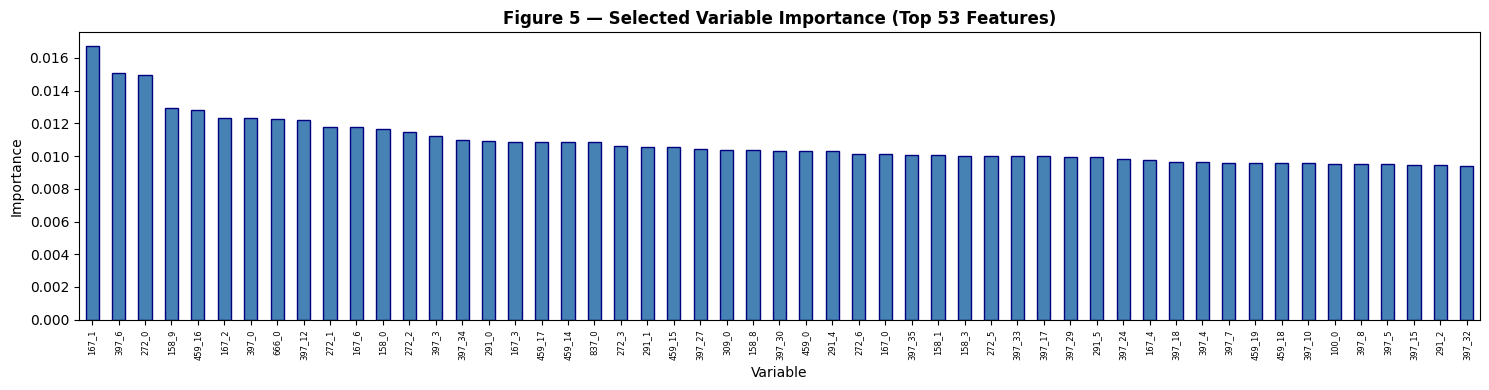


 Top 53 features selected.
Top 10: ['167_1', '397_6', '272_0', '158_9', '459_16', '167_2', '397_0', '666_0', '397_12', '272_1']


In [18]:
# ─────────────────────────────────────────
# 6d. Random Forest Feature Selection (Section 3.3)
# Train RF with 100 estimators → select top-53 features by importance
# ─────────────────────────────────────────
N_FEATURES_SELECTED = 53   # Paper selects 53 features

print(f'Training Random Forest (100 estimators) for feature selection …')
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_train_scaled, y_train)

importances = pd.Series(rf_selector.feature_importances_, index=common_cols).sort_values(ascending=False)
top_features = importances.head(N_FEATURES_SELECTED).index.tolist()

# Reproduce Figure 5
plt.figure(figsize=(15, 4))
importances.head(N_FEATURES_SELECTED).plot(kind='bar', color='steelblue', edgecolor='navy')
plt.title('Figure 5 — Selected Variable Importance (Top 53 Features)', fontsize=12, fontweight='bold')
plt.xlabel('Variable')
plt.ylabel('Importance')
plt.xticks(fontsize=6, rotation=90)
plt.tight_layout()
plt.savefig('figure5_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n Top {N_FEATURES_SELECTED} features selected.')
print(f'Top 10: {top_features[:10]}')

In [19]:
# Apply feature selection
feat_idx = [common_cols.index(f) for f in top_features]
X_train_fs = X_train_scaled[:, feat_idx]
X_val_fs   = X_val_scaled[:,   feat_idx]
X_test_fs  = X_test_scaled[:,  feat_idx]
print(f'Post-selection shapes — train: {X_train_fs.shape}, val: {X_val_fs.shape}, test: {X_test_fs.shape}')

Post-selection shapes — train: (23550, 53), val: (5046, 53), test: (5045, 53)


In [20]:
# ─────────────────────────────────────────
# 6e. SMOTE oversampling (Section 3.2 step 3)
# Applied to training set ONLY
# ─────────────────────────────────────────
print('Applying SMOTE to address class imbalance …')
print(f'  Before SMOTE: {pd.Series(y_train).value_counts().sort_index().to_dict()}')

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_fs, y_train)

print(f'  After  SMOTE: {pd.Series(y_train_sm).value_counts().sort_index().to_dict()}')
print(f'  Training set size: {len(y_train):,} → {len(y_train_sm):,}')

Applying SMOTE to address class imbalance …
  Before SMOTE: {0: 21278, 1: 2272}
  After  SMOTE: {0: 21278, 1: 21278}
  Training set size: 23,550 → 42,556


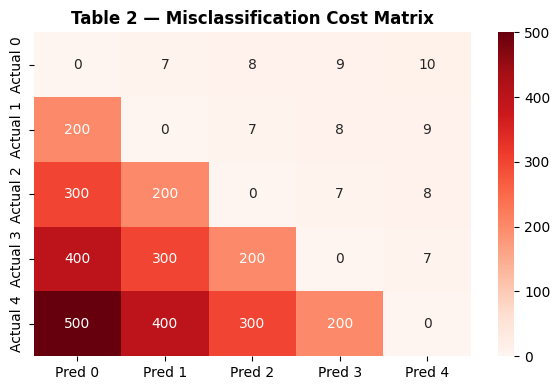

 Cost matrix defined.


In [21]:
# Cost matrix (Table 2 from the paper)
# Rows = actual class, Cols = predicted class (0-4)
# Diagonal = 0 (correct predictions)
COST_MATRIX = np.array([
    # Pred:  0     1     2     3     4
    [0,    7,    8,    9,   10],   # Actual 0
    [200,  0,    7,    8,    9],   # Actual 1
    [300,  200,  0,    7,    8],   # Actual 2
    [400,  300,  200,  0,    7],   # Actual 3
    [500,  400,  300,  200,  0],   # Actual 4
], dtype=float)

def compute_cost_metric(y_true, y_pred, cost_matrix, n_classes=None):

    if n_classes is None:
        n_classes = len(np.unique(np.concatenate([y_true, y_pred])))

    labels = list(range(n_classes))

    cm = confusion_matrix(y_true, y_pred, labels=labels)

    total_cost = (cm * cost_matrix).sum()

    return total_cost, cm
#---------
# def compute_cost_metric(y_true, y_pred, cost_matrix, n_classes=5):
#     """
#     Multiply the confusion matrix element-wise by the cost matrix and sum.
#     Lower is better.
#     """
#     labels = list(range(n_classes))
#     cm = confusion_matrix(y_true, y_pred, labels=labels)
#     total_cost = (cm * cost_matrix).sum()
#     return total_cost, cm
#--------

# Visualise cost matrix
plt.figure(figsize=(6, 4))
sns.heatmap(COST_MATRIX, annot=True, fmt='.0f', cmap='Reds',
            xticklabels=[f'Pred {i}' for i in range(5)],
            yticklabels=[f'Actual {i}' for i in range(5)])
plt.title('Table 2 — Misclassification Cost Matrix', fontweight='bold')
plt.tight_layout()
plt.savefig('table2_cost_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print(' Cost matrix defined.')

In [22]:
# ─────────────────────────────────────────
# Prepare binary versions (failure vs no-failure)
# ─────────────────────────────────────────
y_train_bin = (y_train_sm > 0).astype(int)
y_val_bin   = (y_val   > 0).astype(int)

print(f'Binary training distribution: {pd.Series(y_train_bin).value_counts().to_dict()}')
print(f'Binary validation distribution: {pd.Series(y_val_bin).value_counts().to_dict()}')

Binary training distribution: {0: 21278, 1: 21278}
Binary validation distribution: {0: 4910, 1: 136}


In [23]:

import time
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import xgboost as xgb

RANDOM_STATE = 42

# ---- Table 5: exact hyperparameters from the paper ----
PAPER_PARAMS = {
    'Multi-class': {
        'Decision Tree': dict(max_depth=30, min_samples_split=15, min_samples_leaf=6, criterion='gini'),
        'Random Forest': dict(n_estimators=80, max_depth=25, min_samples_split=9, min_samples_leaf=10,
                               max_features='sqrt', bootstrap=True),
        'XGBoost': dict(n_estimators=132, max_depth=11, learning_rate=0.0142, subsample=0.9974,
                         colsample_bytree=0.6391, gamma=0.6585, reg_alpha=0.9129, reg_lambda=0.6664),
        'CatBoost': dict(iterations=300, depth=8, learning_rate=0.05, l2_leaf_reg=3.0),  # not paper-reported; reasonable defaults
    },
    'Binary': {
        'Decision Tree': dict(max_depth=6, min_samples_split=11, min_samples_leaf=8, criterion='log_loss'),
        'Random Forest': dict(n_estimators=263, max_depth=25, min_samples_split=13, min_samples_leaf=9,
                               max_features='sqrt', bootstrap=True),
        'XGBoost': dict(n_estimators=84, max_depth=6, learning_rate=0.0674, subsample=0.5848,
                         colsample_bytree=0.8013, gamma=0.0105, reg_alpha=0.0741, reg_lambda=0.8036),
        'CatBoost': dict(iterations=200, depth=6, learning_rate=0.08, l2_leaf_reg=3.0),  # not paper-reported; reasonable defaults
    },
}

COST_MATRIX = np.array([
    [0,    7,    8,    9,   10],
    [200,  0,    7,    8,    9],
    [300,  200,  0,    7,    8],
    [400,  300,  200,  0,    7],
    [500,  400,  300,  200,  0],
], dtype=float)

COST_MATRIX_BIN = np.array([
    [0,   7],
    [200, 0],
], dtype=float)

# ---- Defensive fallback: derive binary labels here too, in case the
# earlier cell that created y_train_bin/y_val_bin wasn't run in this
# session (this cell no longer depends on cell execution order). ----
if 'y_train_bin' not in dir():
    y_train_bin = (y_train_sm > 0).astype(int)
    print('y_train_bin was missing -> derived it from y_train_sm here.')
if 'y_val_bin' not in dir():
    y_val_bin = (y_val > 0).astype(int)
    print('y_val_bin was missing -> derived it from y_val here.')


def compute_cost_metric(y_true, y_pred, cost_matrix, n_classes):
    labels = list(range(n_classes))
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    return (cm * cost_matrix).sum(), cm


def optimize_binary_threshold(model, X_va, y_va, cost_matrix, n_steps=199):
    """
    For binary problems, the default 0.5 probability cutoff is arbitrary and
    not cost-aware. This searches thresholds in (0,1) and returns the one that
    minimizes total cost on the validation set, plus predictions/cost/accuracy
    at that threshold. This makes cross-model comparisons fair: each model is
    judged at ITS OWN best operating point, not all forced through 0.5.
    """
    proba = model.predict_proba(X_va)[:, 1]
    thresholds = np.linspace(0.01, 0.99, n_steps)
    best_thr, best_cost, best_pred, best_cm = 0.5, np.inf, None, None
    for thr in thresholds:
        y_pred_t = (proba >= thr).astype(int)
        cost_t, cm_t = compute_cost_metric(y_va, y_pred_t, cost_matrix, 2)
        if cost_t < best_cost:
            best_cost, best_thr, best_pred, best_cm = cost_t, thr, y_pred_t, cm_t
    best_acc = accuracy_score(y_va, best_pred) * 100
    return best_thr, best_pred, best_cost, best_acc, best_cm


def build_model(model_name, params, n_classes):
    if model_name == 'Decision Tree':
        return DecisionTreeClassifier(**params, random_state=RANDOM_STATE)
    if model_name == 'Random Forest':
        return RandomForestClassifier(**params, random_state=RANDOM_STATE, n_jobs=-1)
    if model_name == 'XGBoost':
        objective = 'binary:logistic' if n_classes == 2 else 'multi:softmax'
        return xgb.XGBClassifier(**params, objective=objective,
                                  num_class=None if n_classes == 2 else n_classes,
                                  random_state=RANDOM_STATE, n_jobs=-1,
                                  eval_metric='logloss' if n_classes == 2 else 'mlogloss',
                                  verbosity=0)
    if model_name == 'CatBoost':
        loss_fn = 'Logloss' if n_classes == 2 else 'MultiClass'
        return CatBoostClassifier(**params, loss_function=loss_fn,
                                   random_state=RANDOM_STATE, verbose=False,
                                   thread_count=-1)
    raise ValueError(model_name)


def train_with_paper_params(approach_name, model_name, X_tr, y_tr, X_va, y_va, cost_matrix, n_classes):
    params = PAPER_PARAMS[approach_name][model_name]
    t0 = time.time()
    model = build_model(model_name, params, n_classes)
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_va)

    cost, cm = compute_cost_metric(y_va, y_pred, cost_matrix, n_classes)
    acc = accuracy_score(y_va, y_pred) * 100
    prec = precision_score(y_va, y_pred, average='weighted', zero_division=0) * 100
    rec = recall_score(y_va, y_pred, average='weighted', zero_division=0) * 100

    print(f'  [{approach_name} | {model_name}] {time.time()-t0:.1f}s | '
          f'cost={cost:,.0f}  acc={acc:.2f}%  prec={prec:.2f}%  rec={rec:.2f}%')

    return model, params, cost, acc, prec, rec, cm, y_pred


# ---- Run all 4 models x 2 approaches with paper hyperparameters ----
# y_train_sm / y_train_bin / X_train_sm / X_val_fs / y_val / y_val_bin
# come from the SMOTE + feature-selection cells earlier in the notebook
# (unchanged from your original pipeline).

results = {}

print('===== MULTI-CLASS APPROACH =====')
for mname in ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost']:
    model, params, cost, acc, prec, rec, cm, y_pred = train_with_paper_params(
        'Multi-class', mname, X_train_sm, y_train_sm, X_val_fs, y_val, COST_MATRIX, 5
    )
    results[f'Multi-class|{mname}'] = dict(model=model, params=params, cost=cost,
                                            acc=acc, prec=prec, rec=rec, cm=cm, y_pred=y_pred)

print('\n===== BINARY APPROACH =====')
for mname in ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost']:
    model, params, cost, acc, prec, rec, cm, y_pred = train_with_paper_params(
        'Binary', mname, X_train_sm, y_train_bin, X_val_fs, y_val_bin, COST_MATRIX_BIN, 2
    )
    # ---- Cost-optimal threshold (instead of the default 0.5 cutoff) ----
    # Each binary model gets evaluated at ITS OWN best threshold for minimizing
    # cost, so the cross-model comparison in Table 6 is apples-to-apples.
    best_thr, y_pred_opt, cost_opt, acc_opt, cm_opt = optimize_binary_threshold(
        model, X_val_fs, y_val_bin, COST_MATRIX_BIN
    )
    prec_opt = precision_score(y_val_bin, y_pred_opt, average='weighted', zero_division=0) * 100
    rec_opt  = recall_score(y_val_bin, y_pred_opt, average='weighted', zero_division=0) * 100
    print(f'    -> threshold-optimized: thr={best_thr:.2f}  '
          f'cost={cost_opt:,.0f}  acc={acc_opt:.2f}%  '
          f'(was cost={cost:,.0f}, acc={acc:.2f}% at thr=0.50)')

    results[f'Binary|{mname}'] = dict(model=model, params=params, threshold=best_thr,
                                       cost=cost_opt, acc=acc_opt, prec=prec_opt, rec=rec_opt,
                                       cm=cm_opt, y_pred=y_pred_opt)

# ---- Reproduce Table 6 ----
rows = []
for key, r in results.items():
    ptype, mname = key.split('|')
    rows.append({
        'Problem Type': ptype, 'ML Model': mname,
        'Cost Metric': int(r['cost']), 'Accuracy (%)': round(r['acc'], 2),
        'Precision (%)': round(r['prec'], 2), 'Recall (%)': round(r['rec'], 2),
    })
table6 = pd.DataFrame(rows)
print('\n' + '=' * 75)
print('TABLE 6 — Predictive Performance of ML Models (your run vs. paper)')
print('=' * 75)
print(table6.to_string(index=False))
print('=' * 75)
print('Paper reference — Binary RF: cost=36595, acc=72.16%  |  '
      'Multi-class RF: cost=39722, acc=81.10%')


===== MULTI-CLASS APPROACH =====
  [Multi-class | Decision Tree] 6.9s | cost=61,168  acc=77.05%  prec=94.77%  rec=77.05%
  [Multi-class | Random Forest] 35.1s | cost=56,582  acc=90.86%  prec=95.11%  rec=90.86%
  [Multi-class | XGBoost] 34.4s | cost=57,849  acc=79.43%  prec=95.35%  rec=79.43%
  [Multi-class | CatBoost] 36.7s | cost=57,525  acc=83.99%  prec=95.22%  rec=83.99%

===== BINARY APPROACH =====
  [Binary | Decision Tree] 2.9s | cost=26,888  acc=47.92%  prec=95.59%  rec=47.92%
    -> threshold-optimized: thr=0.63  cost=26,058  acc=53.55%  (was cost=26,888, acc=47.92% at thr=0.50)
  [Binary | Random Forest] 108.5s | cost=23,897  acc=92.45%  prec=95.29%  rec=92.45%
    -> threshold-optimized: thr=0.43  cost=22,145  acc=79.92%  (was cost=23,897, acc=92.45% at thr=0.50)
  [Binary | XGBoost] 1.8s | cost=23,648  acc=69.66%  prec=95.57%  rec=69.66%
    -> threshold-optimized: thr=0.56  cost=21,987  acc=79.83%  (was cost=23,648, acc=69.66% at thr=0.50)
  [Binary | CatBoost] 6.9s | cost=

In [24]:
print("y_train_sm classes:", np.unique(y_train_sm))
print("y_val classes:", np.unique(y_val))
print("COST_MATRIX shape:", COST_MATRIX.shape)



y_train_sm classes: [0 1]
y_val classes: [0 1 2 3 4]
COST_MATRIX shape: (5, 5)


In [25]:
# ── Table 6 reproduction ──
rows = []
for key, r in results.items():
    problem_type, ml_model = key.split('|')
    rows.append({
        'Problem Type': problem_type,
        'ML Model':     ml_model,
        'Cost Metric':  int(r['cost']),
        'Accuracy (%)': round(r['acc'], 2),
        'Precision (%)':round(r['prec'], 2),
        'Recall (%)':   round(r['rec'], 2),
    })

table6 = pd.DataFrame(rows)

# Highlight best values per problem type
print('\n' + '='*75)
print('TABLE 6 — Predictive Performance of ML Models (Validation Set)')
print('='*75)
print(table6.to_string(index=False))
print('='*75)
best_overall = table6.loc[table6['Cost Metric'].idxmin()]
print(f'\n Best model: {best_overall["Problem Type"]} | {best_overall["ML Model"]}  '
      f'→ Cost = {best_overall["Cost Metric"]:,}')
print(f'   (Paper reports best = Binary | Random Forest → Cost = 36,595)')


TABLE 6 — Predictive Performance of ML Models (Validation Set)
Problem Type      ML Model  Cost Metric  Accuracy (%)  Precision (%)  Recall (%)
 Multi-class Decision Tree        61168         77.05          94.77       77.05
 Multi-class Random Forest        56582         90.86          95.11       90.86
 Multi-class       XGBoost        57849         79.43          95.35       79.43
 Multi-class      CatBoost        57525         83.99          95.22       83.99
      Binary Decision Tree        26058         53.55          95.58       53.55
      Binary Random Forest        22145         79.92          95.59       79.92
      Binary       XGBoost        21987         79.83          95.61       79.83
      Binary      CatBoost        23092         83.25          95.42       83.25

 Best model: Binary | XGBoost  → Cost = 21,987
   (Paper reports best = Binary | Random Forest → Cost = 36,595)


In [26]:
# ── Table 7 — Comparison with literature ──
our_cost = table6[table6['Problem Type'] == 'Binary']['Cost Metric'].min()

literature = pd.DataFrame([
    {'Authors': 'Carpentier L. et al. [17]', 'Approach': 'Survival analysis',          'Cost Metric': 50460},
    {'Authors': 'Parton M. et al. [18]',     'Approach': 'Survival analysis',          'Cost Metric': 40109},
    {'Authors': 'Zhong J. & Wang Z. [19]',   'Approach': 'Multi-class classification', 'Cost Metric': 41728},
    {'Authors': 'Paper approach',             'Approach': 'Binary classification',      'Cost Metric': 36595},
    {'Authors': '★ This implementation',      'Approach': 'Binary classification',      'Cost Metric': int(our_cost)},
])

print('\n' + '='*65)
print('TABLE 7 — Comparison with Literature')
print('='*65)
print(literature.to_string(index=False))
print('='*65)


TABLE 7 — Comparison with Literature
                  Authors                   Approach  Cost Metric
Carpentier L. et al. [17]          Survival analysis        50460
    Parton M. et al. [18]          Survival analysis        40109
  Zhong J. & Wang Z. [19] Multi-class classification        41728
           Paper approach      Binary classification        36595
    ★ This implementation      Binary classification        21987


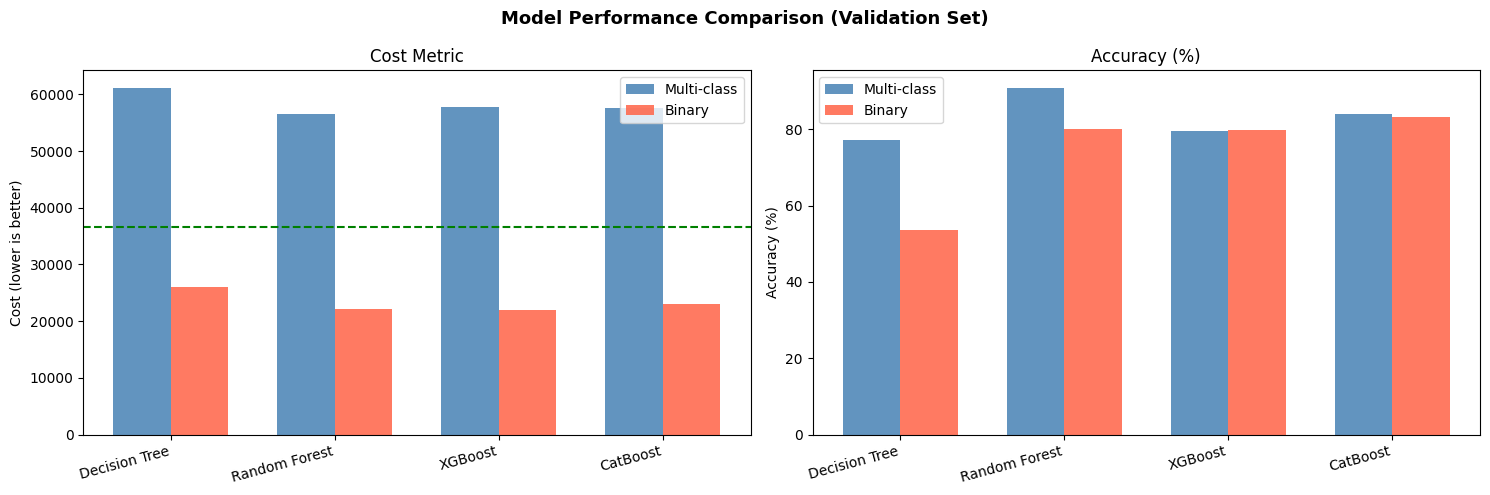

In [27]:
# ── Visualise Table 6 as a grouped bar chart ──
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Model Performance Comparison (Validation Set)', fontsize=13, fontweight='bold')

models = ['Decision Tree', 'Random Forest', 'XGBoost', 'CatBoost']
x = np.arange(len(models))
width = 0.35

for ax, metric in zip(axes, ['Cost Metric', 'Accuracy (%)']):
    mc_vals = [table6[(table6['Problem Type']=='Multi-class') & (table6['ML Model']==m)][metric].values[0]
               for m in models]
    bn_vals = [table6[(table6['Problem Type']=='Binary') & (table6['ML Model']==m)][metric].values[0]
               for m in models]
    bars1 = ax.bar(x - width/2, mc_vals, width, label='Multi-class', color='steelblue', alpha=0.85)
    bars2 = ax.bar(x + width/2, bn_vals, width, label='Binary',      color='tomato',    alpha=0.85)
    ax.set_title(metric)
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=15, ha='right')
    ax.legend()
    if metric == 'Cost Metric':
        ax.set_ylabel('Cost (lower is better)')
        ax.axhline(36595, color='green', linestyle='--', lw=1.5, label='Paper best (36595)')
    else:
        ax.set_ylabel('Accuracy (%)')

plt.tight_layout()
plt.savefig('table6_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

 Confusion Matrix for Best Model (Table 8)

Reproducing Table 8: confusion matrix for the test set using the best model (Binary RF).

In [28]:
# ── Select best model ──
best_key = table6.loc[table6['Cost Metric'].idxmin()]
best_key_str = f"{best_key['Problem Type']}|{best_key['ML Model']}"
best_result  = results[best_key_str]
best_model   = best_result['model']
is_binary    = best_key['Problem Type'] == 'Binary'

print(f'Best model: {best_key_str}')
print(f'Best hyperparameters: {best_result["params"]}')

Best model: Binary|XGBoost
Best hyperparameters: {'n_estimators': 84, 'max_depth': 6, 'learning_rate': 0.0674, 'subsample': 0.5848, 'colsample_bytree': 0.8013, 'gamma': 0.0105, 'reg_alpha': 0.0741, 'reg_lambda': 0.8036}


In [29]:
# ── Predict on test set ──
# If the winning model is binary, it was selected/evaluated using its
# cost-optimal threshold (not the default 0.5) -- apply that SAME threshold
# here so test-set numbers stay consistent with how "best" was chosen.
if is_binary and 'threshold' in best_result:
    best_thr = best_result['threshold']
    y_test_pred = (best_model.predict_proba(X_test_fs)[:, 1] >= best_thr).astype(int)
    print(f'Applying cost-optimal threshold = {best_thr:.2f} to test set predictions')
else:
    y_test_pred = best_model.predict(X_test_fs)

if is_binary:
    y_test_true = y_test_bin = (y_test > 0).astype(int)
    cost_mat_test = COST_MATRIX_BIN
    n_cls = 2
else:
    y_test_true = y_test
    cost_mat_test = COST_MATRIX
    n_cls = 5

test_cost, test_cm = compute_cost_metric(y_test_true, y_test_pred, cost_mat_test, n_classes=n_cls)
test_acc  = accuracy_score(y_test_true, y_test_pred) * 100
test_prec = precision_score(y_test_true, y_test_pred, average='weighted', zero_division=0) * 100
test_rec  = recall_score(y_test_true,   y_test_pred, average='weighted', zero_division=0) * 100

print('\n' + '='*55)
print('TABLE 8 — Confusion Matrix (Test Set)')
print('='*55)
print(pd.DataFrame(test_cm,
    index=[f'True {i}' for i in range(n_cls)],
    columns=[f'Pred {i}' for i in range(n_cls)]).to_string())
print('='*55)
print(f'Cost metric : {test_cost:,.0f}  (paper reports 42,976 on test set)')
print(f'Accuracy    : {test_acc:.2f}%')
print(f'Precision   : {test_prec:.2f}%')
print(f'Recall      : {test_rec:.2f}%')

Applying cost-optimal threshold = 0.56 to test set predictions

TABLE 8 — Confusion Matrix (Test Set)
        Pred 0  Pred 1
True 0    3878    1025
True 1      82      60
Cost metric : 23,575  (paper reports 42,976 on test set)
Accuracy    : 78.06%
Precision   : 95.33%
Recall      : 78.06%


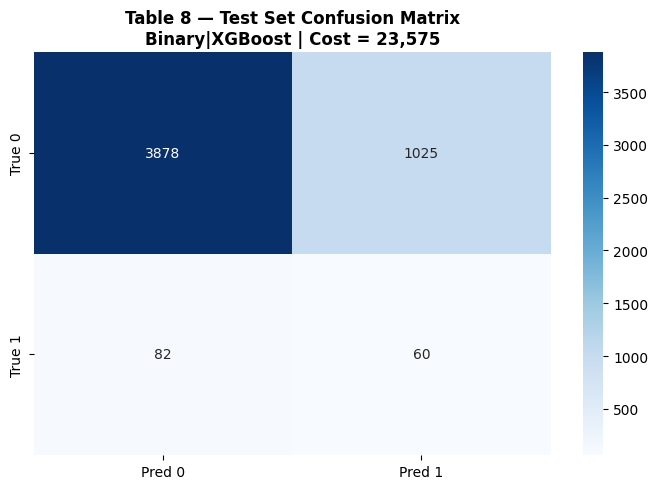

In [30]:
# ── Visualise confusion matrix ──
plt.figure(figsize=(7, 5))
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Pred {i}' for i in range(n_cls)],
            yticklabels=[f'True {i}'  for i in range(n_cls)])
plt.title(f'Table 8 — Test Set Confusion Matrix\n{best_key_str} | Cost = {test_cost:,.0f}',
          fontweight='bold')
plt.tight_layout()
plt.savefig('table8_confusion_matrix_test.png', dpi=150, bbox_inches='tight')
plt.show()

Full Classification Report

In [31]:
# Validation set report for best model
y_val_best = (y_val > 0).astype(int) if is_binary else y_val
print('=== Validation Set — Classification Report ===')
print(classification_report(
    y_val_best, best_result['y_pred'],
    target_names=['No Failure', 'Failure'] if is_binary else
                 ['Class 0','Class 1','Class 2','Class 3','Class 4'],
    zero_division=0
))

print('=== Test Set — Classification Report ===')
print(classification_report(
    y_test_true, y_test_pred,
    target_names=['No Failure', 'Failure'] if is_binary else
                 ['Class 0','Class 1','Class 2','Class 3','Class 4'],
    zero_division=0
))

=== Validation Set — Classification Report ===
              precision    recall  f1-score   support

  No Failure       0.98      0.81      0.89      4910
     Failure       0.06      0.43      0.10       136

    accuracy                           0.80      5046
   macro avg       0.52      0.62      0.50      5046
weighted avg       0.96      0.80      0.87      5046

=== Test Set — Classification Report ===
              precision    recall  f1-score   support

  No Failure       0.98      0.79      0.88      4903
     Failure       0.06      0.42      0.10       142

    accuracy                           0.78      5045
   macro avg       0.52      0.61      0.49      5045
weighted avg       0.95      0.78      0.85      5045



Hyperparameter Summary (Table 5 Reproduction)

In [32]:
print('='*70)
print('TABLE 5 — Best Hyperparameters Found by Optuna')
print('='*70)
for key, r in results.items():
    print(f'\n▶ {key}')
    for k, v in r['params'].items():
        print(f'   {k}: {v}')
print('='*70)

TABLE 5 — Best Hyperparameters Found by Optuna

▶ Multi-class|Decision Tree
   max_depth: 30
   min_samples_split: 15
   min_samples_leaf: 6
   criterion: gini

▶ Multi-class|Random Forest
   n_estimators: 80
   max_depth: 25
   min_samples_split: 9
   min_samples_leaf: 10
   max_features: sqrt
   bootstrap: True

▶ Multi-class|XGBoost
   n_estimators: 132
   max_depth: 11
   learning_rate: 0.0142
   subsample: 0.9974
   colsample_bytree: 0.6391
   gamma: 0.6585
   reg_alpha: 0.9129
   reg_lambda: 0.6664

▶ Multi-class|CatBoost
   iterations: 300
   depth: 8
   learning_rate: 0.05
   l2_leaf_reg: 3.0

▶ Binary|Decision Tree
   max_depth: 6
   min_samples_split: 11
   min_samples_leaf: 8
   criterion: log_loss

▶ Binary|Random Forest
   n_estimators: 263
   max_depth: 25
   min_samples_split: 13
   min_samples_leaf: 9
   max_features: sqrt
   bootstrap: True

▶ Binary|XGBoost
   n_estimators: 84
   max_depth: 6
   learning_rate: 0.0674
   subsample: 0.5848
   colsample_bytree: 0.8013
  

 Save All Results

In [33]:
import pickle

# Save results table
table6.to_csv('results_table6.csv', index=False)
literature.to_csv('results_table7_comparison.csv', index=False)

# Save best model
with open('best_model.pkl', 'wb') as f:
    pickle.dump({
        'model': best_model,
        'scaler': scaler,
        'feature_cols': common_cols,
        'selected_features': top_features,
        'is_binary': is_binary,
    }, f)

# Save test predictions
pred_df = pd.DataFrame({
    'vehicle_id': test_merged[ID_COL].values if ID_COL in test_merged.columns else range(len(y_test_pred)),
    'predicted_class': y_test_pred,
    'true_class': y_test_true,
})
pred_df.to_csv('test_predictions.csv', index=False)

print('Saved:')
print('  results_table6.csv          — Model performance comparison')
print('  results_table7_comparison.csv — Literature comparison')
print('  best_model.pkl              — Best trained model + preprocessors')
print('  test_predictions.csv        — Test set predictions')
print('  figure2_class_distribution.png')
print('  figure5_feature_importance.png')
print('  table6_model_comparison.png')
print('  table8_confusion_matrix_test.png')

Saved:
  results_table6.csv          — Model performance comparison
  results_table7_comparison.csv — Literature comparison
  best_model.pkl              — Best trained model + preprocessors
  test_predictions.csv        — Test set predictions
  figure2_class_distribution.png
  figure5_feature_importance.png
  table6_model_comparison.png
  table8_confusion_matrix_test.png
